# Model A - Simple3DCNN on Kaggle (GPU)

Self-contained: no `src/` imports. Trains the from-scratch 3D CNN with:
  1. A learning-rate sweep run to (near-)saturation, not just 10 epochs
     - this addresses the reviewer's note that short sweeps favour learning
     rates that start fast rather than the best rate for the full run.
  2. A final training run, also to saturation.

Before running:
  - Runtime GPU is on by default on Kaggle (check "Settings > Accelerator > GPU").
  - Upload the clips as a Kaggle Dataset (see the chat instructions) and add it
    to this notebook. Then set CLIP_DIR to the mounted path (under /kaggle/input/...).

## Step 1 -Check GPU

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE - enable GPU in Settings!")

CUDA available: True
GPU: Tesla T4


## Step 2 - Locate the clips

After adding your Kaggle Dataset, the files appear under /kaggle/input/<dataset-name>/.
We search for the train/test _metadata.csv automatically.

In [2]:
import glob, os

CANDIDATES = glob.glob("/kaggle/input/**/train/_metadata.csv", recursive=True)
assert CANDIDATES, "Could not find train/_metadata.csv under /kaggle/input. Did you add the dataset?"
TRAIN_META = CANDIDATES[0]
TEST_META = TRAIN_META.replace("/train/", "/test/")
CLIP_ROOT = os.path.dirname(os.path.dirname(TRAIN_META))
print("Train metadata:", TRAIN_META)
print("Test metadata: ", TEST_META)
print("Clip root:     ", CLIP_ROOT)

Train metadata: /kaggle/input/datasets/lanamatic/ipn-hand-clips/processed/train/_metadata.csv
Test metadata:  /kaggle/input/datasets/lanamatic/ipn-hand-clips/processed/test/_metadata.csv
Clip root:      /kaggle/input/datasets/lanamatic/ipn-hand-clips/processed


## Step 3 - Constants, dataset, model (inline copies of your src/ code)

In [ ]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from sklearn.model_selection import train_test_split

NUM_CLASSES = 13
GESTURE_NAMES = [
    "Point-1f", "Point-2f", "Click-1f", "Click-2f",
    "Throw-up", "Throw-down", "Throw-left", "Throw-right",
    "Open-twice", "DblClick-1f", "DblClick-2f", "Zoom-in", "Zoom-out"
]
IMAGENET_MEAN = np.array([0.43216, 0.394666, 0.37645], dtype=np.float32)
IMAGENET_STD = np.array([0.22803, 0.22145, 0.216989], dtype=np.float32)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def fix_npy_path(p, clip_root):
    """Metadata paths were written locally (../data/processed/...). Rebuild
    them to point at the Kaggle-mounted location using just the filename."""
    name = Path(str(p)).name
    # figure out train vs test from the original path
    sub = "train" if "/train/" in str(p) or "train" in Path(str(p)).parts else "test"
    cand = os.path.join(clip_root, sub, name)
    return cand


class GestureClipDataset(Dataset):
    """Loads (16,112,112,3) uint8 clips -> (3,16,112,112) float tensors."""
    def __init__(self, metadata, clip_root, mean, std, train=False,
                 crop_size=112, resize_to=128):
        if isinstance(metadata, str):
            self.meta = pd.read_csv(metadata)
        else:
            self.meta = metadata.reset_index(drop=True)
        self.clip_root = clip_root
        self.mean, self.std = mean, std
        self.train = train
        self.crop_size = crop_size
        self.resize_to = resize_to

    def __len__(self):
        return len(self.meta)

    def _augment(self, clip):
        cs = self.crop_size
        if self.train:
            rs = self.resize_to
            clip = np.stack([cv2.resize(f, (rs, rs)) for f in clip])
            top = np.random.randint(0, rs - cs + 1)
            left = np.random.randint(0, rs - cs + 1)
            clip = clip[:, top:top+cs, left:left+cs, :]
            if np.random.rand() < 0.5:
                clip = clip[:, :, ::-1, :]
        else:
            clip = np.stack([cv2.resize(f, (cs, cs)) for f in clip])
        return np.ascontiguousarray(clip)

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        clip = np.load(fix_npy_path(row['npy_path'], self.clip_root))
        clip = self._augment(clip)
        clip = clip.astype(np.float32) / 255.0
        clip = (clip - self.mean) / self.std
        clip = np.transpose(clip, (3, 0, 1, 2))  # (C,T,H,W)
        return torch.from_numpy(clip).float(), int(row['label'])


class Simple3DCNN(nn.Module):
    """Conv3D x4 + FC head - same as src/models/cnn3d.py."""
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.5):
        super().__init__()
        def block(ic, oc):
            return nn.Sequential(
                nn.Conv3d(ic, oc, 3, padding=1), nn.BatchNorm3d(oc),
                nn.ReLU(inplace=True), nn.MaxPool3d(2, 2))
        self.features = nn.Sequential(
            block(3, 32), block(32, 64), block(64, 128),
            nn.Conv3d(128, 256, 3, padding=1), nn.BatchNorm3d(256),
            nn.ReLU(inplace=True), nn.AdaptiveAvgPool3d(1))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(256, 128), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(128, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))


def compute_class_weights(meta_df, num_classes=NUM_CLASSES):
    counts = meta_df['label'].value_counts().sort_index()
    freq = np.ones(num_classes, dtype=np.float32)
    for label, c in counts.items():
        freq[int(label)] = c
    w = freq.sum() / (num_classes * freq)
    return torch.from_numpy(w.astype(np.float32))

## Step 4 - Build loaders (stratified train/val split from train metadata)

In [4]:
BATCH_SIZE = 16   # GPU can handle a bigger batch than the local Mac

full_train_meta = pd.read_csv(TRAIN_META)
tr_meta, va_meta = train_test_split(
    full_train_meta, test_size=0.15, stratify=full_train_meta['label'], random_state=42
)
print(f"Train: {len(tr_meta)}   Val: {len(va_meta)}")

class_weights = compute_class_weights(tr_meta).to(DEVICE)

train_ds = GestureClipDataset(tr_meta, CLIP_ROOT, IMAGENET_MEAN, IMAGENET_STD, train=True)
val_ds = GestureClipDataset(va_meta, CLIP_ROOT, IMAGENET_MEAN, IMAGENET_STD, train=False)
test_ds = GestureClipDataset(TEST_META, CLIP_ROOT, IMAGENET_MEAN, IMAGENET_STD, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

xb, yb = next(iter(train_loader))
print("Batch shape:", xb.shape)   # (16,3,16,112,112)

Train: 2649   Val: 468
Batch shape: torch.Size([16, 3, 16, 112, 112])


## Step 5 - Training helpers

In [5]:
import time

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    tot_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            if is_train:
                optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            if is_train:
                loss.backward(); optimizer.step()
            tot_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += x.size(0)
    return tot_loss / total, correct / total


def train_model(model, epochs, lr, patience, use_scheduler, ckpt_path, tag=""):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = (torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=4) if use_scheduler else None)

    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val = float('inf'); no_improve = 0

    for ep in range(1, epochs + 1):
        t0 = time.time()
        tr_l, tr_a = run_epoch(model, train_loader, criterion, optimizer)
        va_l, va_a = run_epoch(model, val_loader, criterion, None)
        if scheduler is not None:
            scheduler.step(va_l)
        hist['train_loss'].append(tr_l); hist['train_acc'].append(tr_a)
        hist['val_loss'].append(va_l); hist['val_acc'].append(va_a)
        print(f"{tag} epoch {ep:2d}/{epochs} | train {tr_l:.3f}/{tr_a:.3f} | "
              f"val {va_l:.3f}/{va_a:.3f} | {time.time()-t0:.0f}s")
        if va_l < best_val:
            best_val = va_l; no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"{tag} early stop at epoch {ep}")
                break
    model.load_state_dict(torch.load(ckpt_path))
    return hist

## Step 6 - Learning-rate sweep, run to saturation

Each lr trains for up to SWEEP_EPOCHS with early stopping, so a slow-but-good
rate is not cut off prematurely. This directly addresses the reviewer's note.

In [6]:
LR_GRID = [1e-2, 3e-3, 1e-3, 3e-4, 1e-4]
SWEEP_EPOCHS = 50          # long enough to reach saturation on GPU
SWEEP_PATIENCE = 8         # stop a run once it plateaus

sweep_histories = {}
for lr in LR_GRID:
    print(f"\n{'='*55}\n  lr = {lr}\n{'='*55}")
    torch.manual_seed(42)
    m = Simple3DCNN(num_classes=NUM_CLASSES).to(DEVICE)
    hist = train_model(m, SWEEP_EPOCHS, lr, SWEEP_PATIENCE, use_scheduler=False,
                       ckpt_path=f"/kaggle/working/sweep_lr_{lr}.pth", tag=f"[lr {lr}]")
    sweep_histories[lr] = hist


  lr = 0.01
[lr 0.01] epoch  1/50 | train 2.508/0.189 | val 2.452/0.246 | 37s
[lr 0.01] epoch  2/50 | train 2.354/0.224 | val 2.549/0.068 | 35s
[lr 0.01] epoch  3/50 | train 2.305/0.236 | val 2.234/0.244 | 36s
[lr 0.01] epoch  4/50 | train 2.258/0.256 | val 2.290/0.220 | 35s
[lr 0.01] epoch  5/50 | train 2.260/0.247 | val 2.266/0.201 | 36s
[lr 0.01] epoch  6/50 | train 2.202/0.243 | val 2.209/0.254 | 36s
[lr 0.01] epoch  7/50 | train 2.164/0.260 | val 2.089/0.280 | 36s
[lr 0.01] epoch  8/50 | train 2.149/0.262 | val 2.185/0.263 | 36s
[lr 0.01] epoch  9/50 | train 2.154/0.227 | val 2.029/0.316 | 36s
[lr 0.01] epoch 10/50 | train 2.122/0.279 | val 1.993/0.316 | 36s
[lr 0.01] epoch 11/50 | train 2.107/0.265 | val 2.056/0.267 | 36s
[lr 0.01] epoch 12/50 | train 2.073/0.260 | val 1.986/0.308 | 36s
[lr 0.01] epoch 13/50 | train 2.044/0.288 | val 2.103/0.286 | 35s
[lr 0.01] epoch 14/50 | train 2.014/0.288 | val 1.907/0.312 | 35s
[lr 0.01] epoch 15/50 | train 2.013/0.301 | val 1.930/0.329 | 3

### Sweep plots

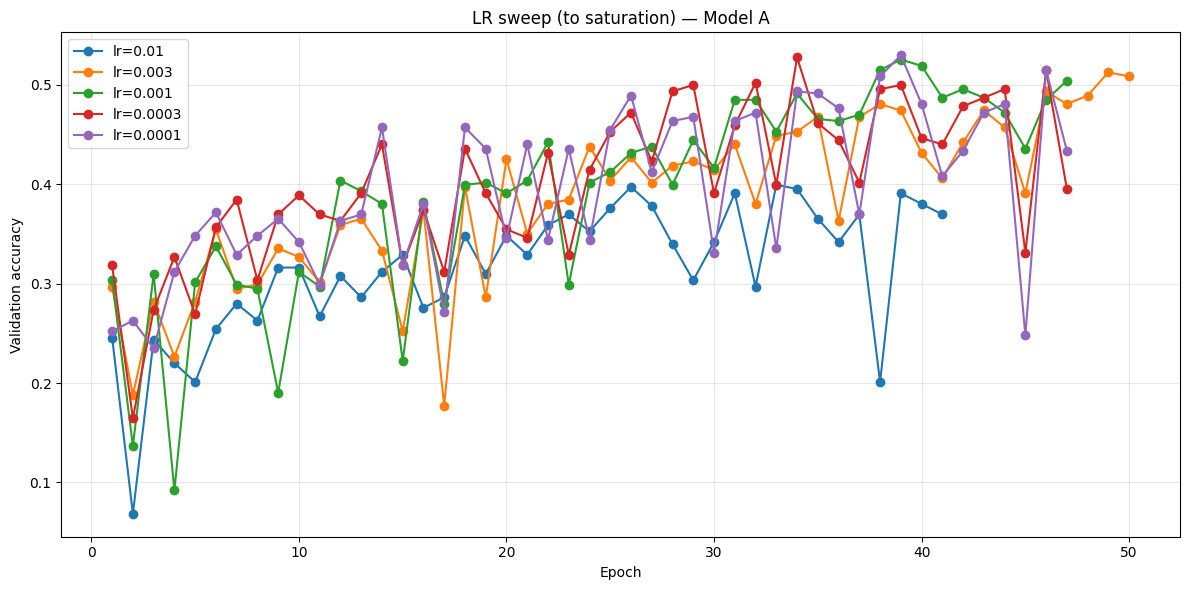

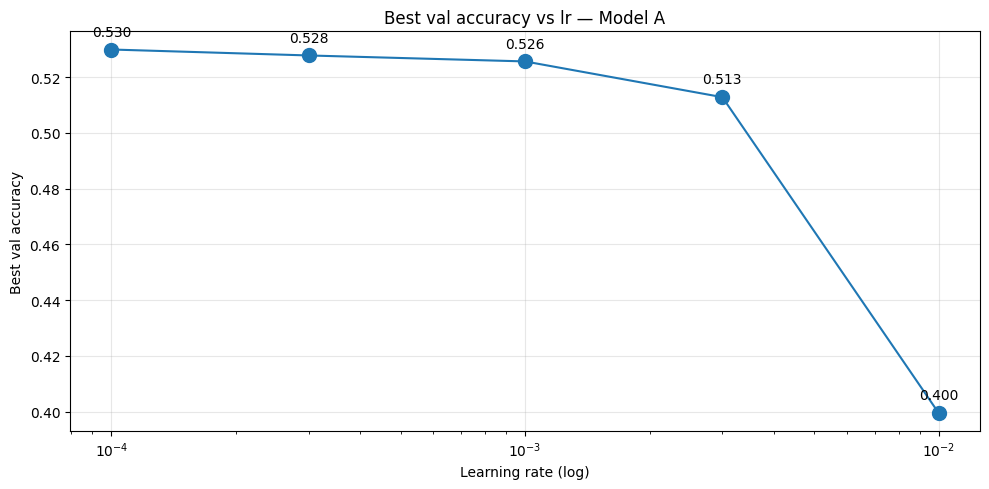


Best lr: 0.0001  (val acc 0.530)
  lr=0.0001   best val acc 0.530
  lr=0.0003   best val acc 0.528
  lr=0.001    best val acc 0.526
  lr=0.003    best val acc 0.513
  lr=0.01     best val acc 0.400


In [ ]:
plt.figure(figsize=(12, 6))
for lr, h in sweep_histories.items():
    plt.plot(range(1, len(h['val_acc']) + 1), h['val_acc'], marker='o', label=f"lr={lr}")
plt.xlabel('Epoch'); plt.ylabel('Validation accuracy')
plt.title('LR sweep (to saturation) - Model A'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("/kaggle/working/lr_sweep_curves_modelA.png", dpi=150, bbox_inches='tight')
plt.show()

best_per_lr = {lr: max(h['val_acc']) for lr, h in sweep_histories.items()}
plt.figure(figsize=(10, 5))
plt.semilogx(list(best_per_lr.keys()), list(best_per_lr.values()), marker='o', markersize=10)
for lr, v in best_per_lr.items():
    plt.annotate(f"{v:.3f}", (lr, v), textcoords="offset points", xytext=(0, 10), ha='center')
plt.xlabel('Learning rate (log)'); plt.ylabel('Best val accuracy')
plt.title('Best val accuracy vs lr - Model A'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("/kaggle/working/lr_sweep_best_modelA.png", dpi=150, bbox_inches='tight')
plt.show()

best_lr_a = max(best_per_lr, key=best_per_lr.get)
print(f"\nBest lr: {best_lr_a}  (val acc {best_per_lr[best_lr_a]:.3f})")
for lr, v in sorted(best_per_lr.items(), key=lambda x: -x[1]):
    print(f"  lr={lr:<8} best val acc {v:.3f}")

## Step 7 - Final training with best lr, to saturation

Longer patience so it truly plateaus before stopping.

[final] epoch  1/80 | train 2.477/0.233 | val 2.389/0.252 | 36s
[final] epoch  2/80 | train 2.322/0.284 | val 2.353/0.263 | 36s
[final] epoch  3/80 | train 2.252/0.281 | val 2.301/0.235 | 36s
[final] epoch  4/80 | train 2.195/0.305 | val 2.157/0.312 | 36s
[final] epoch  5/80 | train 2.145/0.310 | val 2.099/0.348 | 36s
[final] epoch  6/80 | train 2.069/0.332 | val 2.027/0.372 | 36s
[final] epoch  7/80 | train 2.015/0.331 | val 2.104/0.329 | 36s
[final] epoch  8/80 | train 1.982/0.344 | val 1.993/0.348 | 36s
[final] epoch  9/80 | train 1.946/0.357 | val 1.889/0.365 | 36s
[final] epoch 10/80 | train 1.880/0.354 | val 1.944/0.342 | 36s
[final] epoch 11/80 | train 1.844/0.368 | val 1.940/0.299 | 36s
[final] epoch 12/80 | train 1.817/0.388 | val 2.006/0.363 | 36s
[final] epoch 13/80 | train 1.771/0.380 | val 1.873/0.370 | 36s
[final] epoch 14/80 | train 1.723/0.408 | val 1.716/0.457 | 36s
[final] epoch 15/80 | train 1.677/0.402 | val 1.978/0.318 | 36s
[final] epoch 16/80 | train 1.665/0.408 

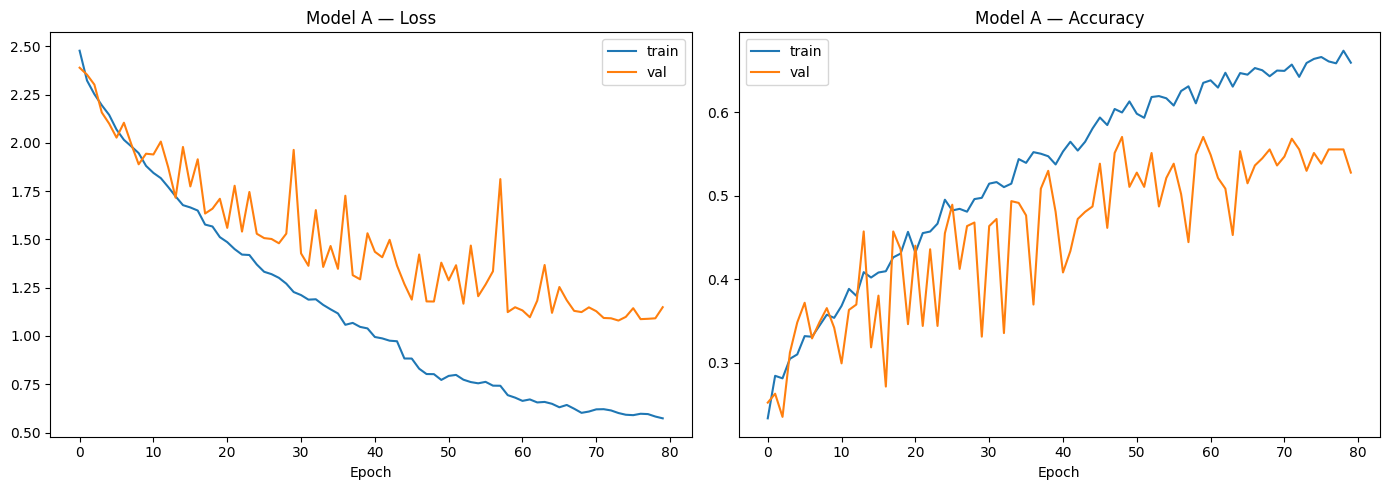

In [ ]:
torch.manual_seed(42)
model_a = Simple3DCNN(num_classes=NUM_CLASSES).to(DEVICE)
history_a = train_model(model_a, epochs=80, lr=best_lr_a, patience=15,
                        use_scheduler=True,
                        ckpt_path="/kaggle/working/model_a_scratch_best.pth",
                        tag="[final]")

# curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_a['train_loss'], label='train'); axes[0].plot(history_a['val_loss'], label='val')
axes[0].set_title('Model A - Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history_a['train_acc'], label='train'); axes[1].plot(history_a['val_acc'], label='val')
axes[1].set_title('Model A - Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.savefig("/kaggle/working/history_modelA.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 8 - Evaluate on the test set

Accuracy: 0.5577  F1_w: 0.5542  F1_m: 0.5606  Top3: 0.9101  Top5: 0.9619

               precision    recall  f1-score   support

    Point-1f       0.59      0.40      0.48       265
    Point-2f       0.55      0.70      0.61       264
    Click-1f       0.32      0.33      0.32        52
    Click-2f       0.31      0.29      0.30        52
    Throw-up       0.91      0.62      0.74        52
  Throw-down       0.78      0.77      0.78        52
  Throw-left       0.65      0.69      0.67        52
 Throw-right       0.71      0.67      0.69        52
  Open-twice       0.66      0.71      0.69        52
 DblClick-1f       0.42      0.40      0.41        52
 DblClick-2f       0.44      0.63      0.52        52
     Zoom-in       0.45      0.60      0.51        52
    Zoom-out       0.61      0.54      0.57        52

    accuracy                           0.56      1101
   macro avg       0.57      0.56      0.56      1101
weighted avg       0.57      0.56      0.55      1101



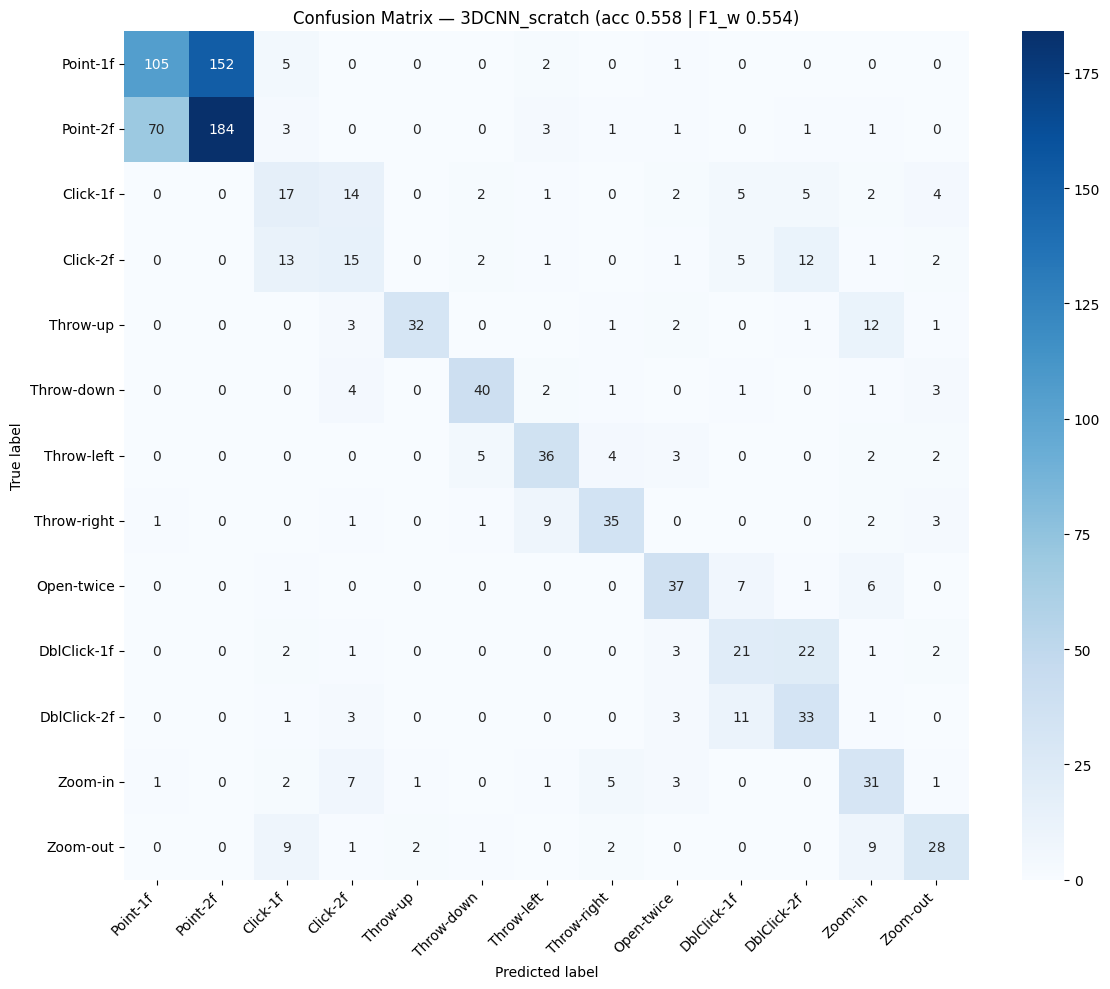

In [ ]:
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, top_k_accuracy_score)
import seaborn as sns

@torch.no_grad()
def predict(model, loader):
    model.eval()
    yt, yp, ypr = [], [], []
    for x, y in loader:
        x = x.to(DEVICE)
        prob = torch.softmax(model(x), dim=1).cpu().numpy()
        ypr.append(prob); yp.append(prob.argmax(1)); yt.append(y.numpy())
    return np.concatenate(yt), np.concatenate(yp), np.concatenate(ypr)

y_true, y_pred, y_prob = predict(model_a, test_loader)

acc = accuracy_score(y_true, y_pred)
f1_w = f1_score(y_true, y_pred, average='weighted')
f1_m = f1_score(y_true, y_pred, average='macro')
top3 = top_k_accuracy_score(y_true, y_prob, k=3)
top5 = top_k_accuracy_score(y_true, y_prob, k=5)
print(f"Accuracy: {acc:.4f}  F1_w: {f1_w:.4f}  F1_m: {f1_m:.4f}  Top3: {top3:.4f}  Top5: {top5:.4f}")
print("\n", classification_report(y_true, y_pred, target_names=GESTURE_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GESTURE_NAMES, yticklabels=GESTURE_NAMES)
plt.title(f'Confusion Matrix - 3DCNN_scratch (acc {acc:.3f} | F1_w {f1_w:.3f})')
plt.ylabel('True label'); plt.xlabel('Predicted label')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig("/kaggle/working/confusion_3DCNN_scratch.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 9 - Save results (download from Kaggle "Output" tab afterwards)

In [ ]:
import json

results = {
    'model': '3DCNN_scratch',
    'approach': 'raw video clip (3D CNN, from scratch)',
    'accuracy': float(acc), 'f1_weighted': float(f1_w), 'f1_macro': float(f1_m),
    'top3_accuracy': float(top3), 'top5_accuracy': float(top5),
    'best_lr': float(best_lr_a),
    'config': {'architecture': 'Conv3D x4 + FC head', 'batch_size': BATCH_SIZE,
               'optimizer': 'Adam', 'dropout': 0.5, 'n_frames': 16, 'resolution': 112,
               'sweep_epochs': SWEEP_EPOCHS, 'final_epochs_max': 80},
}
with open("/kaggle/working/3dcnn_scratch_results.json", "w") as f:
    json.dump(results, f, indent=2)

np.savez("/kaggle/working/predictions_modelA.npz",
         y_true=y_true, y_pred=y_pred, y_prob=y_prob)

print(json.dumps(results, indent=2))
print("\nSaved to /kaggle/working/ - download from the Output tab:")
print("  3dcnn_scratch_results.json, predictions_modelA.npz,")
print("  model_a_scratch_best.pth, confusion_3DCNN_scratch.png,")
print("  history_modelA.png, lr_sweep_curves_modelA.png, lr_sweep_best_modelA.png")

{
  "model": "3DCNN_scratch",
  "approach": "raw video clip (3D CNN, from scratch)",
  "accuracy": 0.5576748410535877,
  "f1_weighted": 0.5542270922871176,
  "f1_macro": 0.5606187380455998,
  "top3_accuracy": 0.9100817438692098,
  "top5_accuracy": 0.9618528610354223,
  "best_lr": 0.0001,
  "config": {
    "architecture": "Conv3D x4 + FC head",
    "batch_size": 16,
    "optimizer": "Adam",
    "dropout": 0.5,
    "n_frames": 16,
    "resolution": 112,
    "sweep_epochs": 50,
    "final_epochs_max": 80
  }
}

Saved to /kaggle/working/ — download from the Output tab:
  3dcnn_scratch_results.json, predictions_modelA.npz,
  model_a_scratch_best.pth, confusion_3DCNN_scratch.png,
  history_modelA.png, lr_sweep_curves_modelA.png, lr_sweep_best_modelA.png
